In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.getcwd()


'c:\\Users\\hamoud\\Desktop\\Iris_dataset'

In [89]:
data = pd.read_csv('iris_dataset.csv')
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [90]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=['target'])
y = data['target']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, stratify=y)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(112, 4) (38, 4) (112,) (38,)


In [91]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output= False, handle_unknown= 'ignore')
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, StratifiedKFold



In [92]:
num_data = X_train.select_dtypes(include = [np.number]).columns
cat_data = X_train.select_dtypes(exclude = [np.number]).columns
num_pipeline = Pipeline([
    ("imputer", imputer),
    ("scaler", scaler)
])
cat_pipeline = Pipeline([
    ("OneHotEncoder", cat_encoder)
])
preprocessing = ColumnTransformer([
    ("num_col", num_pipeline, num_data),
    ("cat_col", cat_pipeline, cat_data)
])

In [93]:
from sklearn.linear_model import LogisticRegression
model_Log_Reg_SMR = LogisticRegression(max_iter=200)
Logistic_regression_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", model_Log_Reg_SMR)
])


In [94]:
Logistic_regression_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_col', ...), ('cat_col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [95]:
y_pred = Logistic_regression_pipeline.predict(X_test)
y_pred

array([2, 0, 2, 1, 0, 2, 0, 2, 2, 0, 1, 1, 0, 1, 2, 1, 0, 0, 2, 1, 0, 2,
       2, 1, 0, 1, 0, 2, 2, 1, 1, 1, 0, 0, 1, 1, 1, 2])

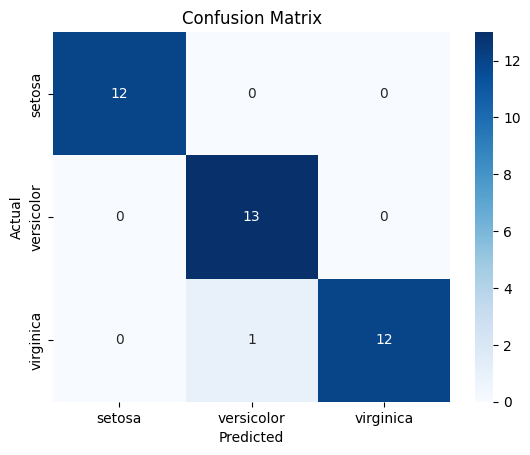

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=["setosa","versicolor","virginica"],
            yticklabels=["setosa","versicolor","virginica"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [97]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(Logistic_regression_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print("Cross-validation accuracies:", scores)
print("Mean CV accuracy:", scores.mean())

Cross-validation accuracies: [0.95652174 0.86956522 1.         0.95454545 0.95454545]
Mean CV accuracy: 0.9470355731225297


In [98]:
y_test_pred = Logistic_regression_pipeline.predict(X_test)
from sklearn.metrics import accuracy_score
print("Test set accuracy:", accuracy_score(y_test, y_test_pred))

Test set accuracy: 0.9736842105263158
